In [2]:
from db_connect import get_engine, query_to_df, test_connection
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

2026-01-27 21:11:20 | INFO    | db_connect | Loaded .env from: C:\Users\Sajal\Desktop\Vendor-Performance-Analysis\.env


In [3]:
engine=get_engine()
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", engine)
df.head()

2026-01-27 21:11:21 | INFO    | db_connect | Engine created for database: vendor_performance


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ReferencePurchasePrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalExciseTax,VendorTotalFreight,EstimatedGrossProfitProxy,AvgSalesPrice_imputed,GrossMarginPct,SellThroughRatio,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,23.86,750.0,8.0,190.88,18.0,...,2.00,27.08,474.02,36.99,28.8066,2.2500,474.94,71.3316,2.2500,3.4882
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,17.00,162.5,320.0,5440.00,24.0,...,0.52,27.08,-4866.40,24.99,150.0000,0.0750,-4840.24,-50.0000,0.0750,0.1103
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,105.07,3750.0,1.0,105.07,0.0,...,0.00,0.48,-105.55,156.57,0.0000,0.0000,-105.07,0.0000,0.0000,0.0000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,11.44,750.0,39.0,446.16,47.0,...,37.01,367.52,256.23,14.99,63.6311,1.2051,258.37,36.6727,1.2051,1.5791
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,11.10,1750.0,6.0,66.60,0.0,...,0.00,367.52,-66.92,16.54,0.0000,0.0000,-66.60,0.0000,0.0000,0.0000


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.000000,7153.00000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.00,5793.500000,18761.50000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.840000,10.45500,19.482500,5.681810e+03
ReferencePurchasePrice,10692.0,24.385303,109.269375,0.36,6.840000,10.45500,19.482500,5.681810e+03
Volume,10692.0,847.360550,664.309212,50.00,750.000000,750.00000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.000000,262.00000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.457500,3655.46500,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.00,33.000000,261.00000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.00,729.220000,5298.04500,28396.915000,5.101920e+06
AvgSalesPrice,10692.0,35.305281,153.819597,0.49,10.490750,15.65475,27.990000,8.466970e+03


# Histograms

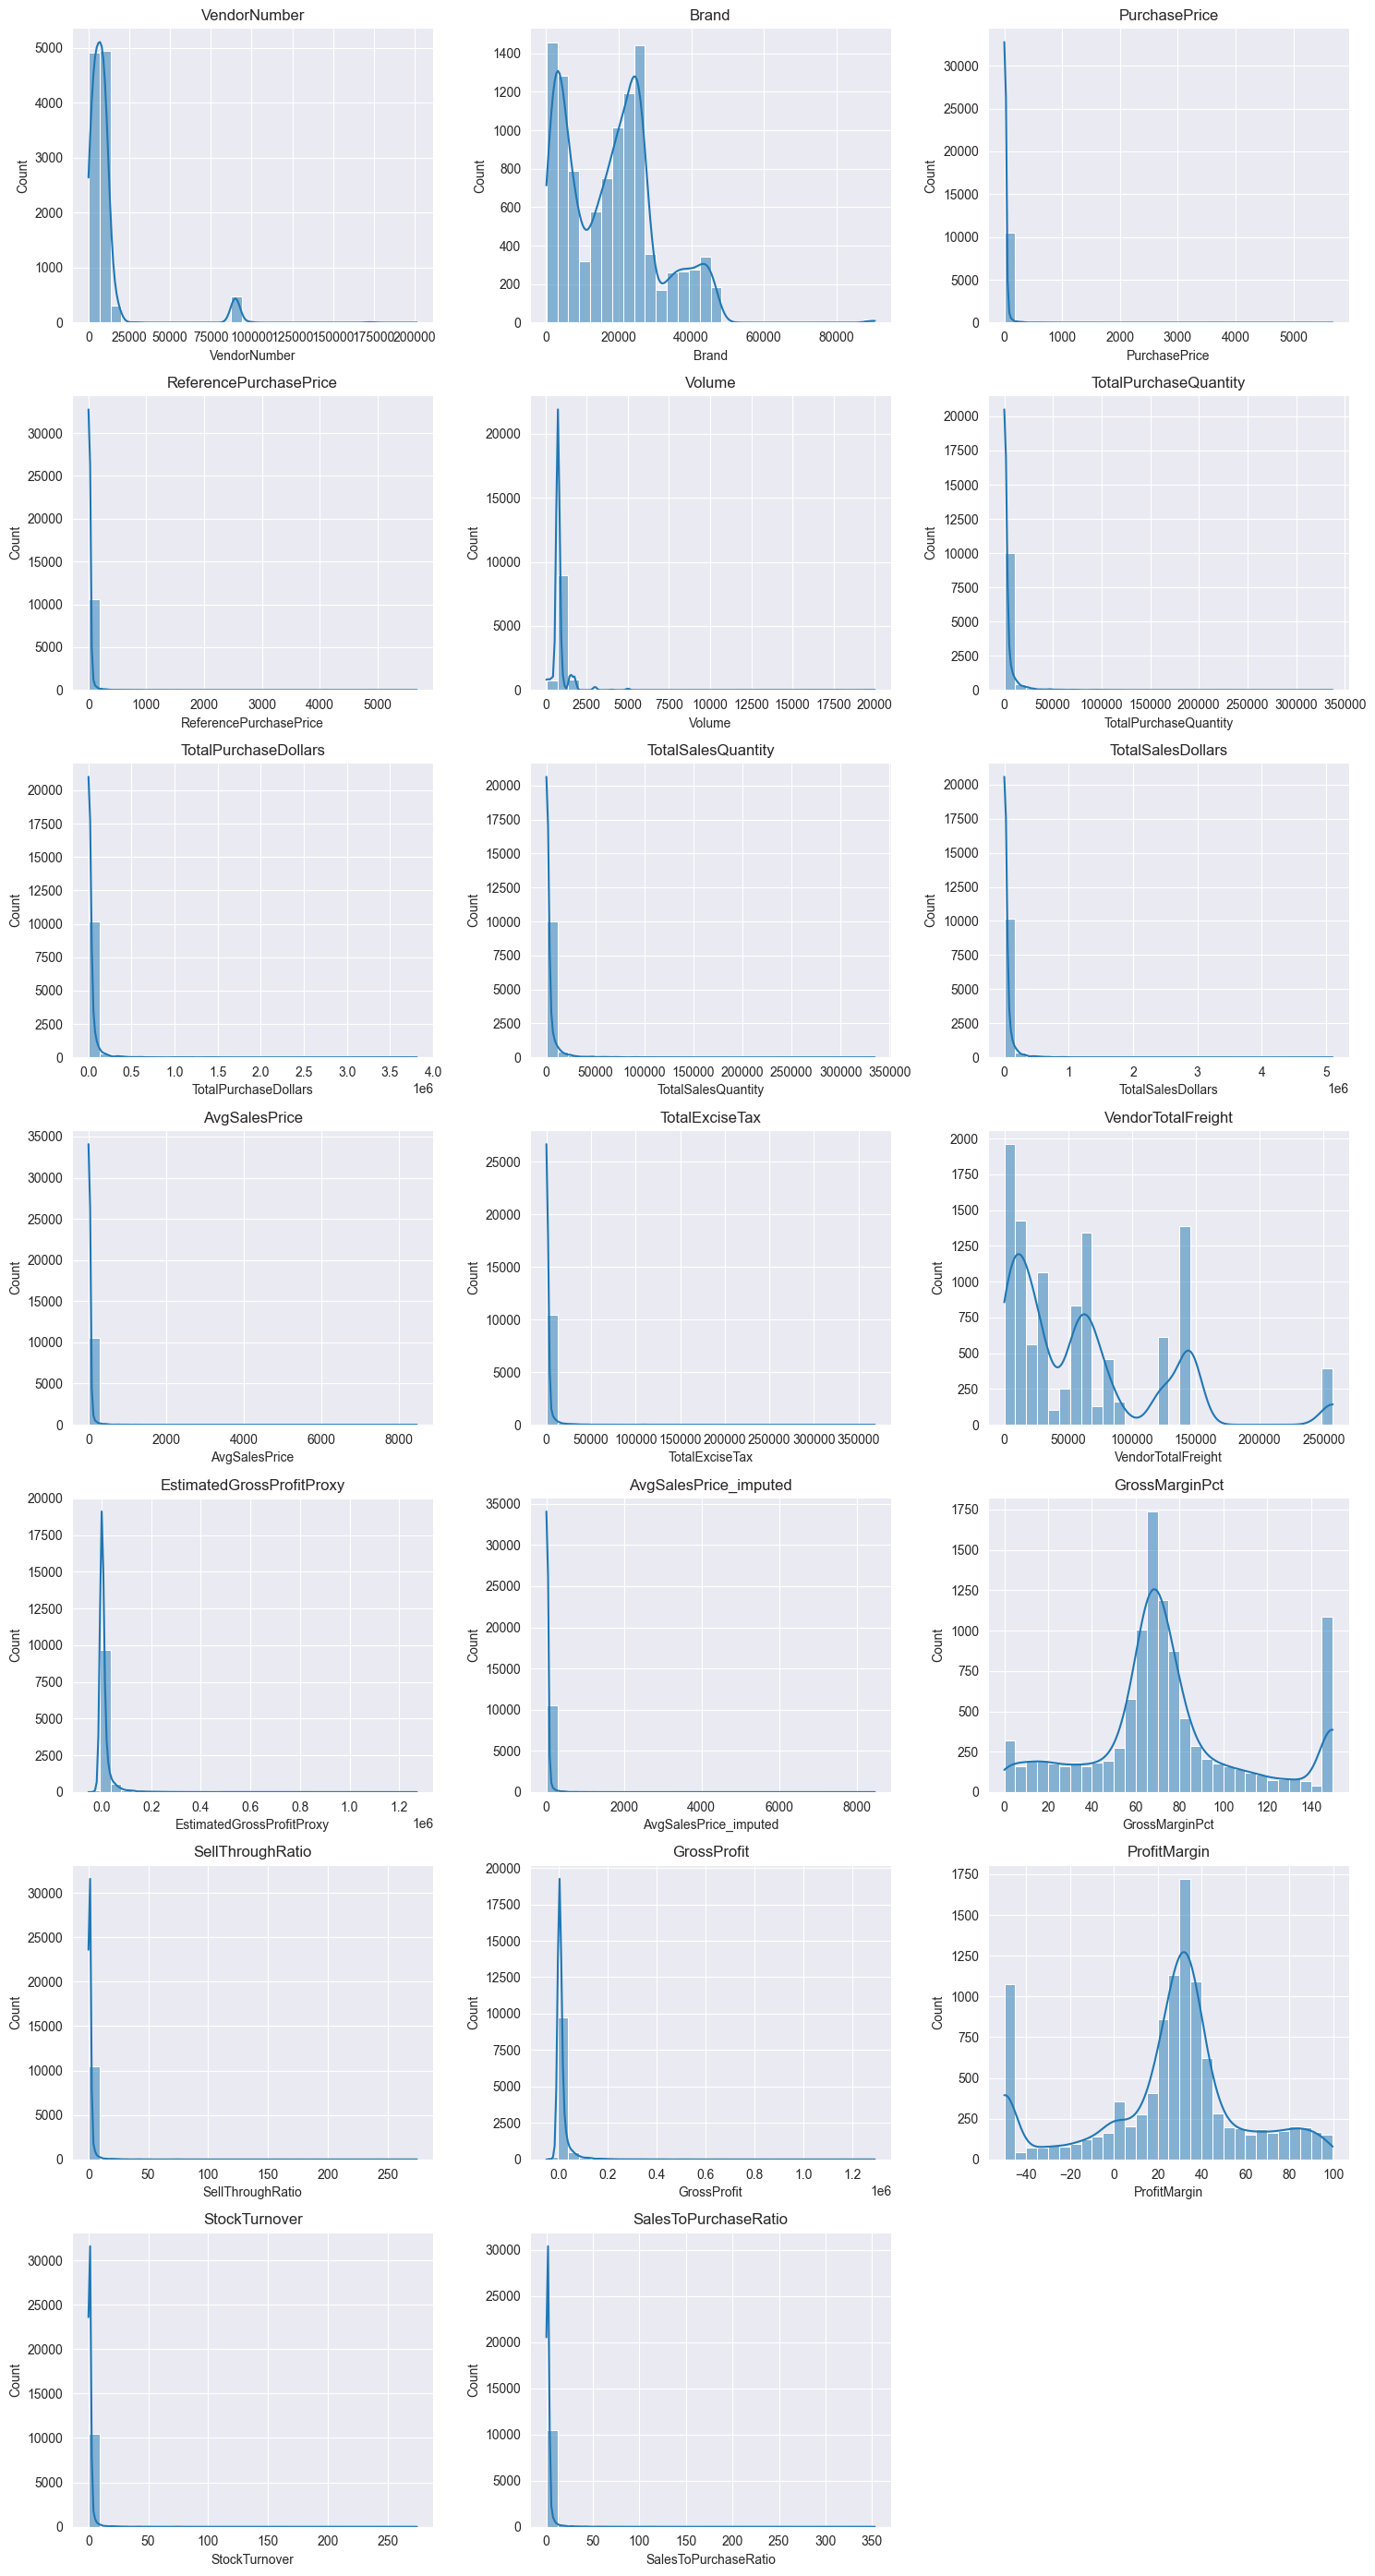

In [7]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)

cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


# Box Plot to check *Outliers*

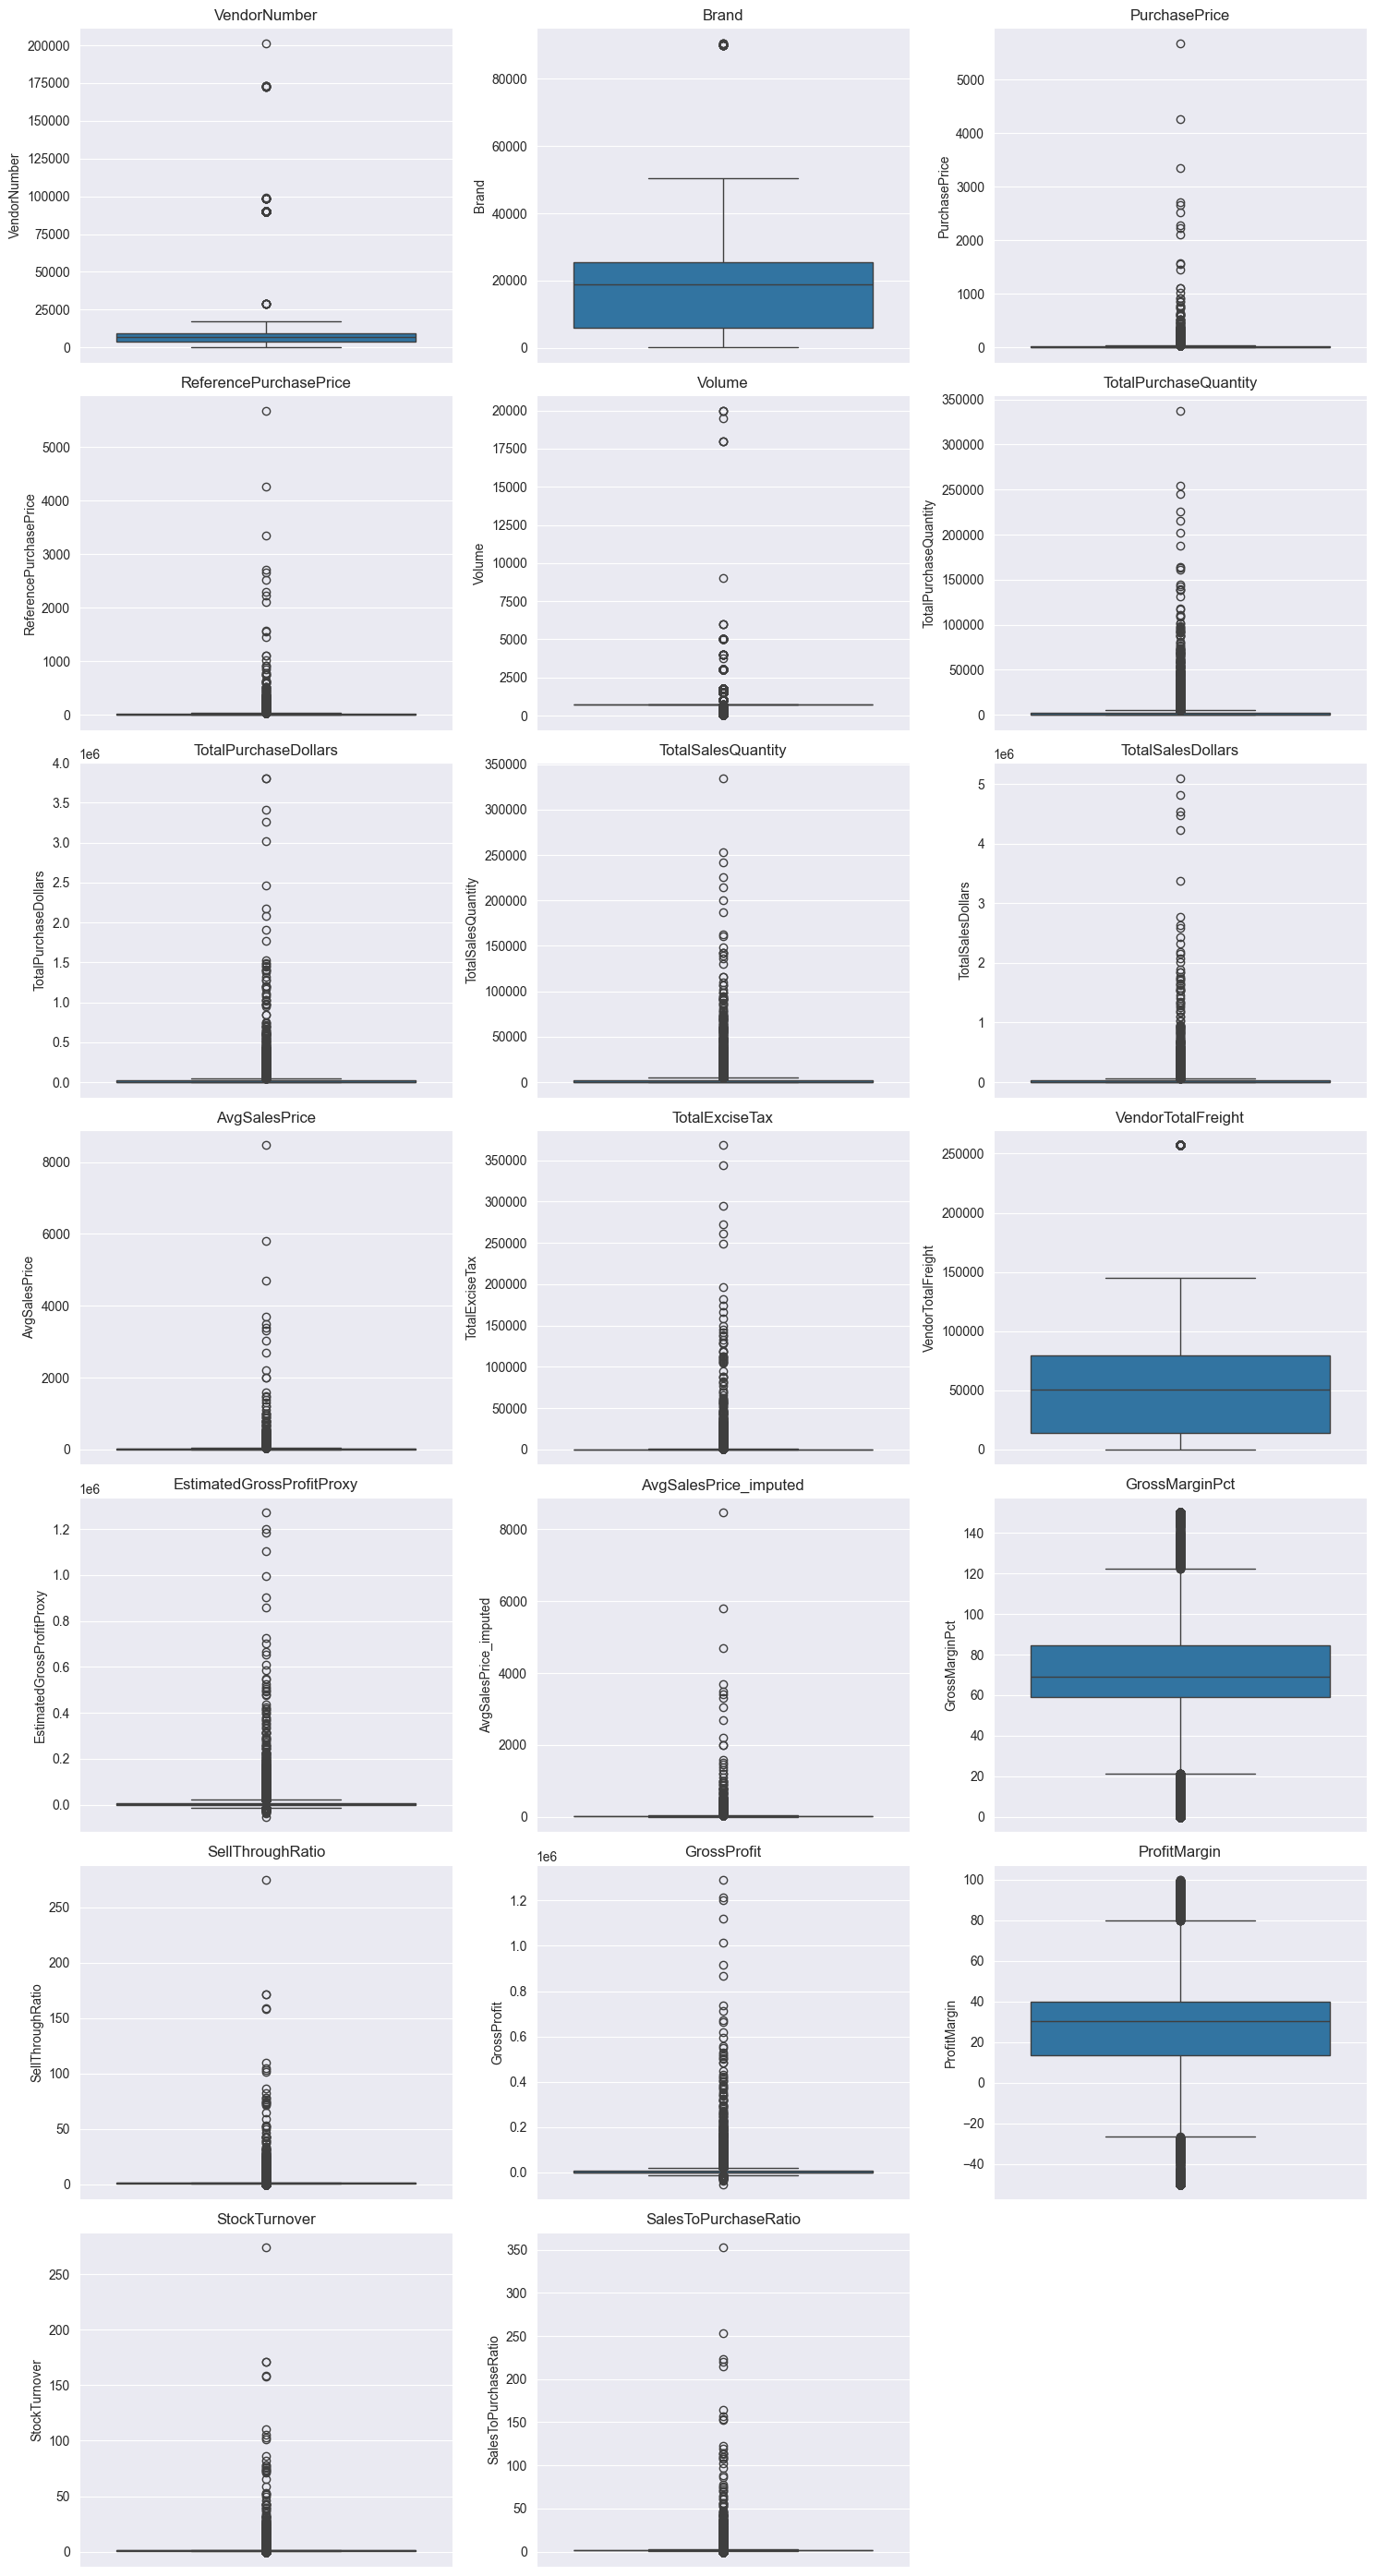

In [8]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



## **Summary Statistics – Key Insights**

### **1. Negative and Zero Values: Business Risk Signals**

* **Gross Profit**
  The minimum gross profit of **–52,002.78** indicates instances of **loss-making transactions or products**. This may result from:

  * Selling prices below procurement cost,
  * Aggressive discounting strategies,
  * High logistics or overhead costs not recovered through sales.
    These cases warrant **product-level profitability analysis** and pricing review.

* **Profit Margin**
  The presence of **–∞ (negative infinity)** values suggests transactions with **zero or near-zero revenue** while costs were incurred. This typically occurs when:

  * Items were purchased but not sold,
  * Revenue entries are missing or delayed,
  * Returns or write-offs were recorded without corresponding sales.
    Such records should be **validated or excluded** before downstream modeling.

* **Total Sales Quantity & Sales Dollars**
  Minimum values of **0** indicate products that were **procured but never sold**. These represent:

  * Slow-moving or obsolete inventory,
  * Overstocking issues,
  * Demand forecasting inaccuracies.
    These items contribute to **inventory holding costs and capital lock-in**.

---

### **2. Outliers & High Dispersion: Structural Variability in Operations**

* **Purchase Price & Actual Price**
  While mean prices remain relatively low (**24.39 and 35.64**), maximum values reach **5,681.81 and 7,499.99**, indicating:

  * A **highly skewed price distribution**,
  * Presence of **premium or specialty products**,
  * A non-homogeneous product portfolio.
    Price-sensitive analyses should therefore use **median or segmented pricing** rather than global averages.

* **Freight Cost**
  Freight costs range from **0.09 to 257,032.07**, reflecting extreme variability. This suggests:

  * Bulk or long-distance shipments,
  * Vendor-dependent logistics contracts,
  * Possible inefficiencies or cost anomalies.
    Freight costs should be **normalized per unit or per order** for fair comparison.

* **Stock Turnover Ratio**
  Stock turnover spans from **0 to 274.5**, indicating highly uneven inventory movement:

  * Values near **0** highlight non-moving inventory,
  * Extremely high values indicate **rapid sell-through**, often fulfilled from **existing stock reserves** rather than recent purchases.
    A turnover ratio **greater than 1** implies sales exceeding current-period purchases, reflecting reliance on **opening inventory** rather than anomalies.

---

### **3. Analytical Implications**

* The data exhibits **heavy skewness, extreme outliers, and structural zeros**, making it unsuitable for naïve mean-based analysis.
* Robust statistics (median, IQR), **log transformations**, and **outlier handling** are recommended prior to:

  * Predictive modeling,
  * Profitability analysis,
  * Vendor or product benchmarking.
* Segmentation by **product category, vendor, or price tier** will yield more actionable insights than aggregate analysis.

---

In [ ]:
# df = pd.read_sql_query(
#     """
#     SELECT *
#     FROM vendor_sales_summary
#     WHERE GrossProfit > 0
#       AND ProfitMargin > 0
#       AND TotalSalesQuantity > 0
#     """,
#     engine
# )



## Issues with Current Data Filtering Approach

```python
df = pd.read_sql_query(
    """
    SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
      AND ProfitMargin > 0
      AND TotalSalesQuantity > 0
    """,
    engine
)
````

---

### Exclusion of Negative and Zero Profit Records

#### Problem

Filtering out records with `GrossProfit ≤ 0` and `ProfitMargin ≤ 0` removes all loss-making transactions from the dataset.

#### Business Reality

Negative margins are not anomalies; they frequently occur due to:

* **Loss leaders** (strategic pricing below cost)
* **Clearance and liquidation sales**
* **Product returns, damages, or defects**
* **Seasonal or promotional discounting**

#### Analytical Impact

Removing these records prevents:

* Identification of **underperforming or loss-generating products**
* Analysis of **systematic loss patterns**
* Accurate computation of **overall portfolio profitability**

➡ This leads to an **overly optimistic and biased dataset**.

---

### Overly Restrictive Zero-Sales Filtering

#### Problem

Filtering out records with `TotalSalesQuantity = 0` eliminates products that have not yet recorded sales.

#### Business Interpretation of Zero Sales

Products with zero sales may represent:

* **Dead or obsolete stock** (inventory risk)
* **Recently procured items** (timing mismatch between purchase and sales)
* **Slow-moving inventory** requiring pricing, marketing, or stocking interventions

#### Analytical Impact

Excluding zero-sales items prevents:

* Proper **inventory turnover analysis**
* Detection of **stock accumulation and capital lock-in**
* Identification of **early-stage performance risks**

➡These records are **critical for supply chain and inventory optimization**.

---

### Overall Risk of the Current Approach

* Introduces **selection bias**
* Masks operational inefficiencies
* Eliminates critical failure signals
* Produces misleading EDA and KPIs

---

### Recommended Practice

* Retain negative, zero, and low-performance records
* Handle anomalies using:

  * Segmentation
  * Robust statistics (median, IQR)
  * Flagging instead of filtering
* Apply filtering **only at the modeling or use-case level**, not during raw EDA

---

*Good analytics surfaces problems — it does not hide them.*



In [10]:
from scipy import stats

# Load full dataset first
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", engine)

# Define function to remove extreme outliers using IQR method
def remove_outliers_iqr(df, column, factor=3.0):
    """
    Remove outliers beyond factor * IQR from Q1/Q3
    factor=3.0 is lenient (only removes extreme values)
    factor=1.5 is standard but more aggressive
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to key metrics (adjust columns as needed)
df_clean = df.copy()

# Remove extreme outliers for continuous metrics
for col in ['PurchasePrice', 'TotalPurchaseDollars', 'TotalSalesDollars',
            'VendorTotalFreight', 'GrossProfit', 'StockTurnover']:
    df_clean = remove_outliers_iqr(df_clean, col, factor=3.0)

# Handle percentage/ratio columns separately (cap rather than remove)
df_clean['ProfitMargin'] = df_clean['ProfitMargin'].clip(-50, 150)
df_clean['GrossMarginPct'] = df_clean['GrossMarginPct'].clip(-50, 150)
df_clean['SellThroughRatio'] = df_clean['SellThroughRatio'].clip(0, 5)

print(f"Original rows: {len(df):,}")
print(f"After outlier removal: {len(df_clean):,}")
print(f"Removed: {len(df) - len(df_clean):,} ({(1 - len(df_clean)/len(df))*100:.1f}%)")

Original rows: 10,692
After outlier removal: 7,441
Removed: 3,251 (30.4%)


In [12]:
print(df.shape)
print(df_clean.shape)

(10692, 22)
(7441, 22)


In [14]:
display(df_clean)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ReferencePurchasePrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalExciseTax,VendorTotalFreight,EstimatedGrossProfitProxy,AvgSalesPrice_imputed,GrossMarginPct,SellThroughRatio,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,17.00,162.5,320.0,5440.00,24.0,...,0.52,27.08,-4866.40,24.9900,150.0000,0.0750,-4840.24,-50.0000,0.0750,0.1103
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,11.44,750.0,39.0,446.16,47.0,...,37.01,367.52,256.23,14.9900,63.6311,1.2051,258.37,36.6727,1.2051,1.5791
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,11.10,1750.0,6.0,66.60,0.0,...,0.00,367.52,-66.92,16.5400,0.0000,0.0000,-66.60,0.0000,0.0000,0.0000
5,60,ADAMBA IMPORTS INTL INC,3979,Vesica Potato Vodka,16.27,16.27,1750.0,4687.0,76257.49,3931.0,...,7224.06,367.52,-9750.87,17.0202,114.5815,0.8387,-9385.80,-14.0355,0.8387,0.8769
6,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,23.25,750.0,12.0,279.00,12.0,...,9.44,62.39,79.39,29.9900,77.9399,1.0000,80.88,22.4742,1.0000,1.2899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10686,172662,SWEETWATER FARM,4215,Kingfish Silver Rum,19.40,19.40,750.0,224.0,4345.60,129.0,...,101.75,178.34,-1015.22,25.9900,130.2806,0.5759,-992.89,-29.6146,0.5759,0.7715
10687,173357,TAMWORTH DISTILLING,2804,Camp Robber Whiskey,32.14,32.14,750.0,210.0,6749.40,140.0,...,110.33,202.50,-484.11,44.9900,107.6860,0.6667,-450.80,-7.1571,0.6667,0.9332
10688,173357,TAMWORTH DISTILLING,3666,Art in the Age Chicory Root,18.79,18.79,375.0,520.0,9770.80,360.0,...,141.19,202.50,-822.62,24.9900,109.1439,0.6923,-774.40,-8.6079,0.6923,0.9207
10689,173357,TAMWORTH DISTILLING,3848,Chicory Root Vodka,23.30,23.30,750.0,28.0,652.40,6.0,...,4.71,202.50,-469.68,30.9900,150.0000,0.2143,-466.46,-50.0000,0.2143,0.2850


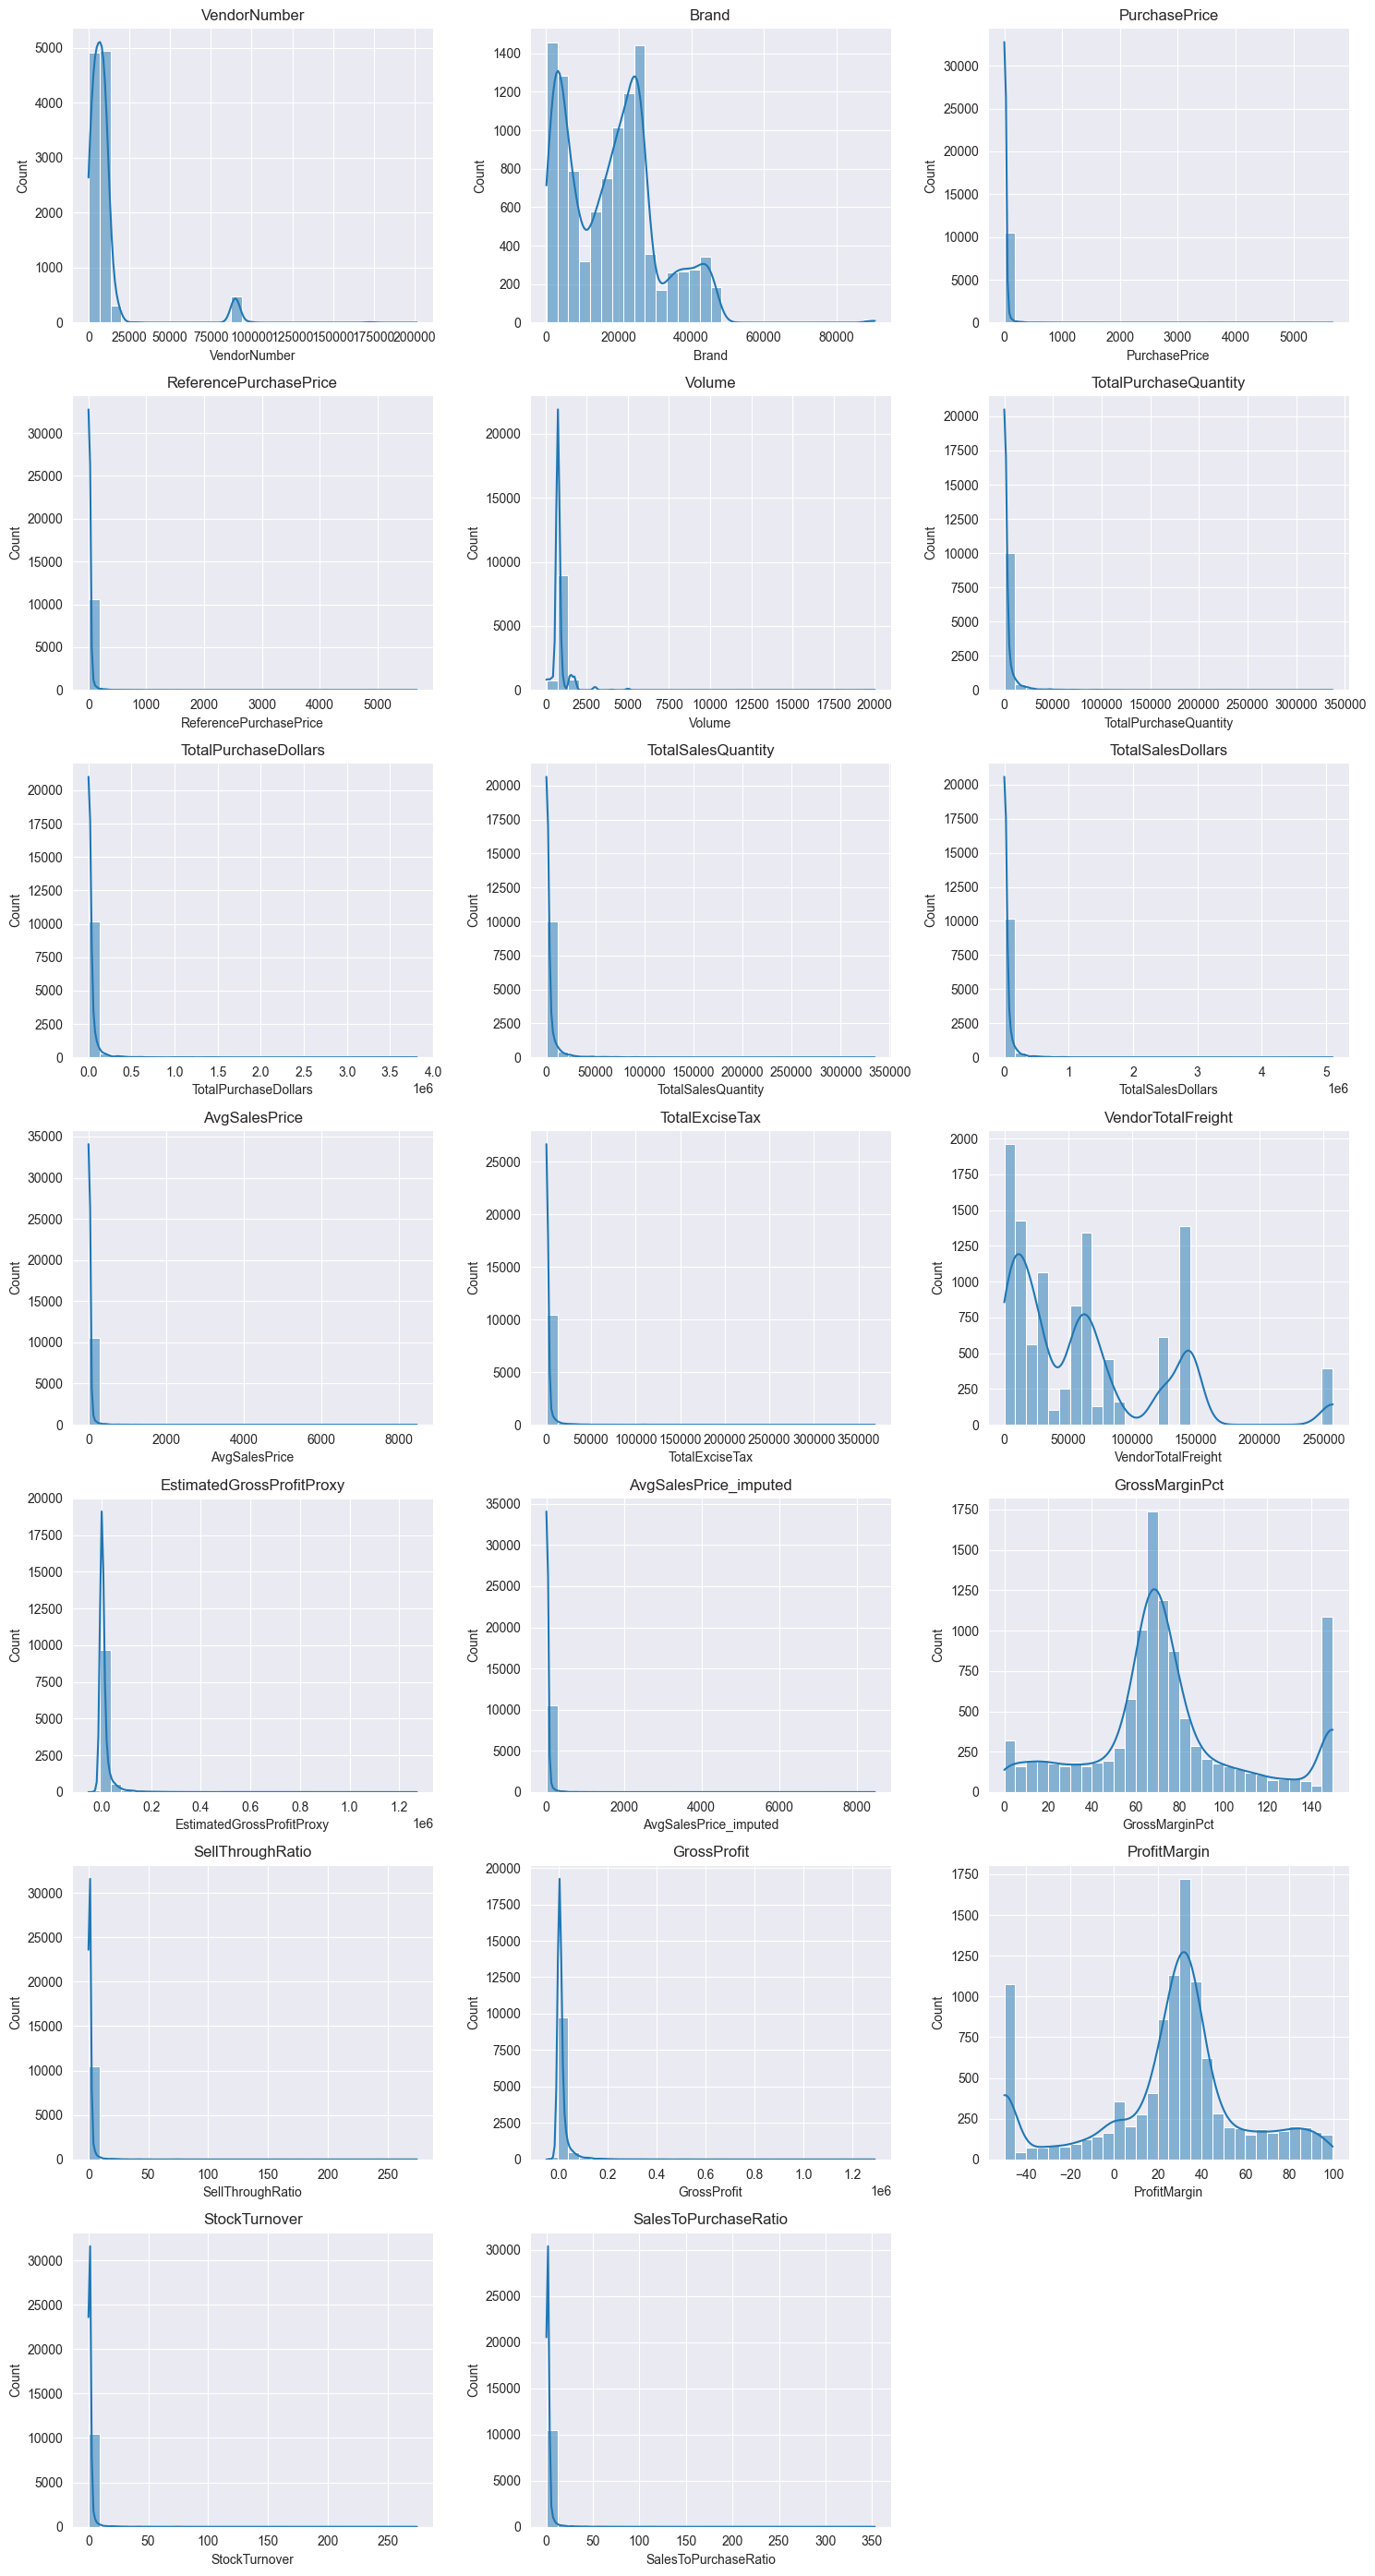

In [15]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)

cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


**Apply log transformation for modeling/correlation analysis**

In [16]:
import numpy as np

# Create log-transformed versions for analysis
price_cols = ['PurchasePrice', 'ReferencePurchasePrice', 'AvgSalesPrice', 'AvgSalesPrice_imputed']

for col in price_cols:
    # Add small constant to handle zeros, then log-transform
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])  # log1p = log(1 + x)

# Use the _log versions for:
# - Correlation heatmaps
# - Regression models
# - Clustering
# Keep original versions for business reporting

# Volume Distribution Still Problematic
What you see: Extreme spike at 750 (most common bottle size), with scattered outliers up to 20,000
**Why it matters:**

* Volume should be categorical (750ml, 1L, 1.75L are standard sizes)
* Treating it as continuous adds noise

In [17]:
# Define standard bottle sizes
def categorize_volume(vol):
    if vol <= 200:
        return 'Mini (≤200ml)'
    elif vol <= 500:
        return 'Half (200-500ml)'
    elif vol <= 1000:
        return 'Standard (750ml-1L)'
    elif vol <= 2000:
        return 'Large (1-2L)'
    else:
        return 'XL (>2L)'

df_clean['VolumeCategory'] = df_clean['Volume'].apply(categorize_volume)

# Use VolumeCategory for grouping/filtering instead of raw Volume

# GrossProfit Shows Potential Bimodal Distribution
**What you see:** Small peak near 0, then larger peak around 50-100, suggesting two distinct groups <br>
**Why it matters:** May indicate fundamentally different product types (low-margin vs high-margin)

In [18]:
# Split into low-margin and high-margin products
df_clean['MarginTier'] = pd.cut(
    df_clean['GrossProfit'],
    bins=[-np.inf, 10, 100, np.inf],
    labels=['Low Profit (<$10)', 'Medium Profit ($10-100)', 'High Profit (>$100)']
)

# Analyze characteristics of each tier
print(df_clean.groupby('MarginTier').agg({
    'Brand': 'count',
    'PurchasePrice': 'mean',
    'Volume': 'median',
    'ProfitMargin': 'mean',
    'StockTurnover': 'mean'
}).round(2))

                         Brand  PurchasePrice  Volume  ProfitMargin  \
MarginTier                                                            
Low Profit (<$10)         2033          16.06   750.0        -29.99   
Medium Profit ($10-100)    751          10.37   750.0         24.19   
High Profit (>$100)       4657          12.49   750.0         32.28   

                         StockTurnover  
MarginTier                              
Low Profit (<$10)                 0.43  
Medium Profit ($10-100)           0.92  
High Profit (>$100)               1.01  


In [19]:
# 1. Check for perfect correlations (might indicate duplicate columns)
correlation_matrix = df_clean[[
    'PurchasePrice', 'ReferencePurchasePrice',
    'AvgSalesPrice', 'AvgSalesPrice_imputed'
]].corr()

print("Highly correlated pairs (>0.95):")
print(correlation_matrix[(correlation_matrix > 0.95) & (correlation_matrix < 1.0)].stack())

# 2. Verify no negative quantities remain
print("\nNegative values check:")
print(df_clean[['TotalPurchaseQuantity', 'TotalSalesQuantity']].min())

# 3. Check for suspiciously round numbers (data entry artifacts)
print("\nRound number check (% ending in .00):")
for col in ['TotalPurchaseDollars', 'TotalSalesDollars']:
    round_pct = (df_clean[col] % 1 == 0).sum() / len(df_clean) * 100
    print(f"{col}: {round_pct:.1f}%")

Highly correlated pairs (>0.95):
PurchasePrice           AvgSalesPrice             0.983678
                        AvgSalesPrice_imputed     0.983678
ReferencePurchasePrice  AvgSalesPrice             0.983678
                        AvgSalesPrice_imputed     0.983678
AvgSalesPrice           PurchasePrice             0.983678
                        ReferencePurchasePrice    0.983678
AvgSalesPrice_imputed   PurchasePrice             0.983678
                        ReferencePurchasePrice    0.983678
dtype: float64

Negative values check:
TotalPurchaseQuantity    1.0
TotalSalesQuantity       0.0
dtype: float64

Round number check (% ending in .00):
TotalPurchaseDollars: 4.1%
TotalSalesDollars: 2.7%


In [20]:
from scipy import stats

# Test normality for key business metrics
metrics_to_test = ['GrossProfit', 'ProfitMargin', 'StockTurnover', 'SellThroughRatio']

print("\nNormality Tests (Shapiro-Wilk):")
print("p < 0.05 means NOT normal (bad for some statistical tests)\n")

for col in metrics_to_test:
    # Use sample if dataset is large (Shapiro-Wilk limit = 5000)
    sample = df_clean[col].dropna().sample(min(5000, len(df_clean)))
    stat, p_value = stats.shapiro(sample)

    print(f"{col}:")
    print(f"  p-value: {p_value:.4f}")
    print(f"  {'✅ Normal' if p_value > 0.05 else '⚠️ NOT Normal (consider transformation)'}")
    print()


Normality Tests (Shapiro-Wilk):
p < 0.05 means NOT normal (bad for some statistical tests)

GrossProfit:
  p-value: 0.0000
  ⚠️ NOT Normal (consider transformation)

ProfitMargin:
  p-value: 0.0000
  ⚠️ NOT Normal (consider transformation)

StockTurnover:
  p-value: 0.0000
  ⚠️ NOT Normal (consider transformation)

SellThroughRatio:
  p-value: 0.0000
  ⚠️ NOT Normal (consider transformation)



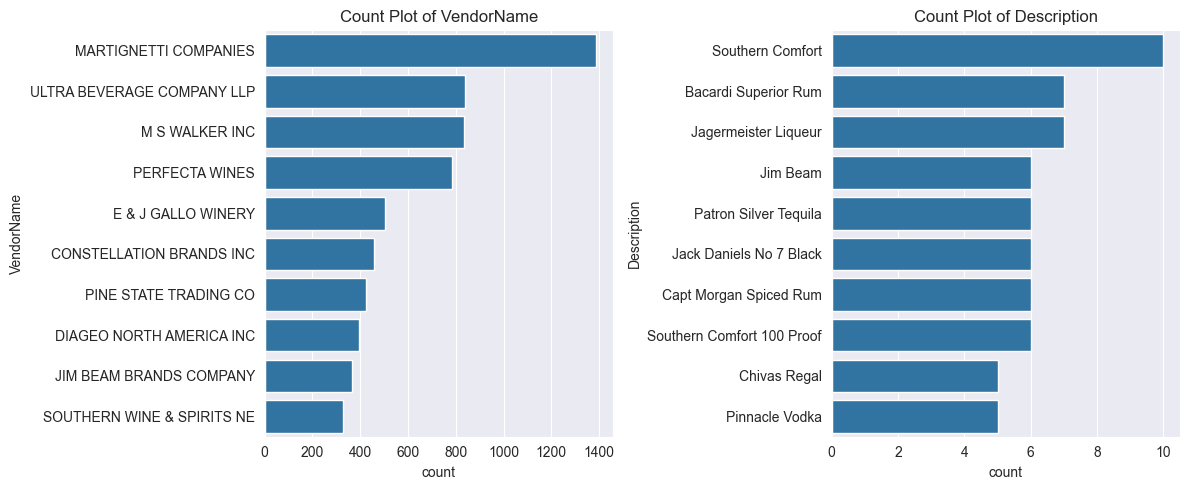

In [23]:
 # Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

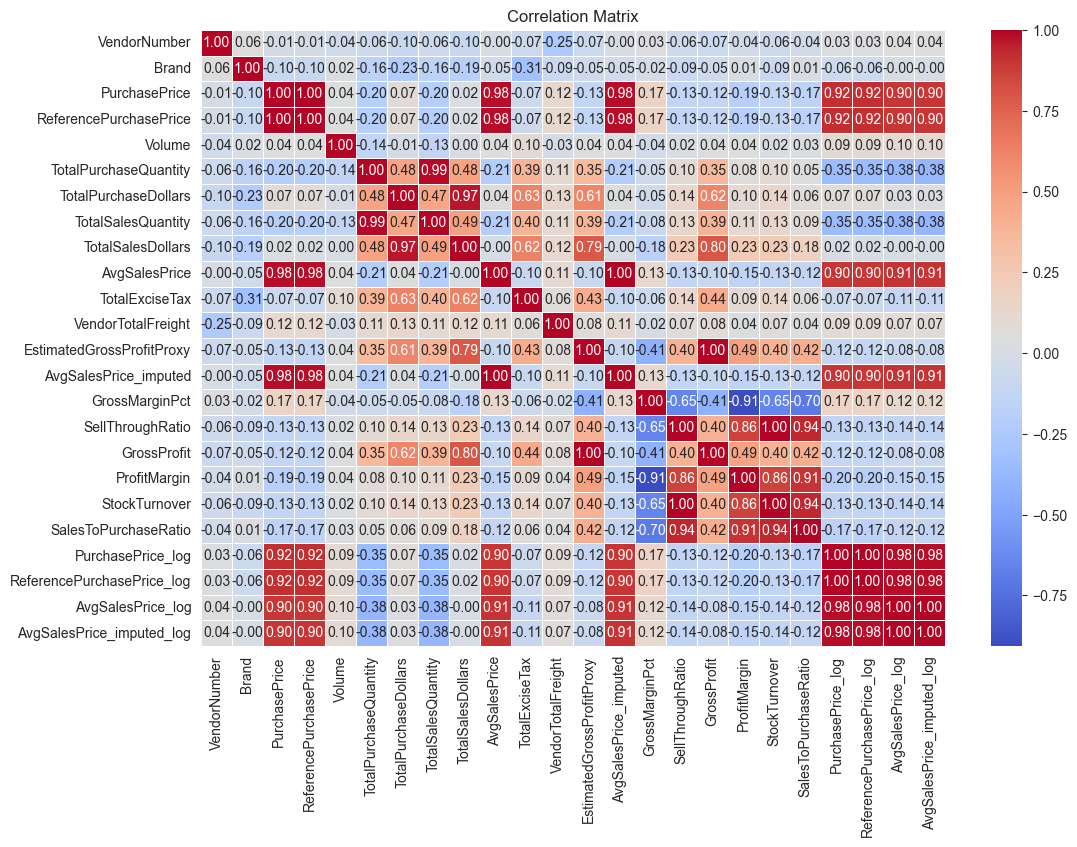

In [24]:
numerical_cols_clean = df_clean.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
cor_matrix = df_clean[numerical_cols_clean].corr()
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title("Correlation Matrix")
plt.show()